In [4]:
# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "elo-meriem"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "elo-meriem" in remote_url:
    print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
    print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

#today_dir = "Comparative Experiments"
today_dir = "Assignments"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/elo-meriem/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design
⚠️ WARNING: You are working in the instructor's repo, not your fork!
💡 Please fork the repo to your own account and update `github_username` above.
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments


# Homework 1: Completely Randomized Designs
## Dr. Austin R. Brown
### School of Data Science & Analytics
### Kennesaw State University

**DUE: February 6, 2026**

**INSTRUCTIONS:** You are a quality control analyst for a craft brewery experimenting with a new India Pale Ale (IPA). One key quality attribute of IPA is its bitterness, measured in International Bitterness Units (IBUs). The brewery wants to determine if the aging time (3, 4, or 5 weeks) affects the IBUs of the beer. To test this, the brewing team brews a single batch of the experimental IPA and divides it into aging tanks, with each tank randomly assigned to be aged for 3, 4, or 5 weeks. After aging, the IBUs of ten randomly selected bottles from each aging time are measured using a spectrophotometer. The data are in the file `IPA.xlsx`. With these data, I want you to:

**Question 1.** Briefly define the objective of this experiment

Determine which of the aging time (3,4, or 5 weeks )affects the IBUs of the beer

**Question 2.** Specify the outcome variable
International Bitterness Units (IBUs)

**Question 3.** Specify the independent variable. What are some possible lurking variables?

the IV: the aging time (3,4 ,5 weeeks) :categorical variable

possible lurking variables:
temperature
light
tank material


**Question 4.** Briefly explain why a completely randomized design may be appropriate for this experiment.

A completely randomized design is appropriate for this experiment because all experimental units (the aging tanks and bottles) come from the same homogeneous batch of beer. Each tank has an equal probability of receiving an aging time, and the bottles are randomly selected for IBU measurement. This allows differences in IBUs to be attributed primarily to aging time rather than lurking variables

**Question 5.** State the null and alternative hypotheses for this experiment.

the null hypothesis,  H0 , is that all the tanks_IBUs means are equal.

H0:μ3=μ4=μ5

the alternative hypothesis,  H1 , is that at least two of the group means differ.

H1: at least of of μ3,μ4,μ5 is different

**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?

The results support the alternative hypothesis

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Weeks   30 non-null     object 
 1   IBU     30 non-null     float64
dtypes: float64(1), object(1)
memory usage: 612.0+ bytes
None
           mean       std
Weeks                    
3 Weeks  49.216  8.300656
4 Weeks  62.751  8.250384
5 Weeks  69.725  5.631258


Text(0, 0.5, 'IBU')

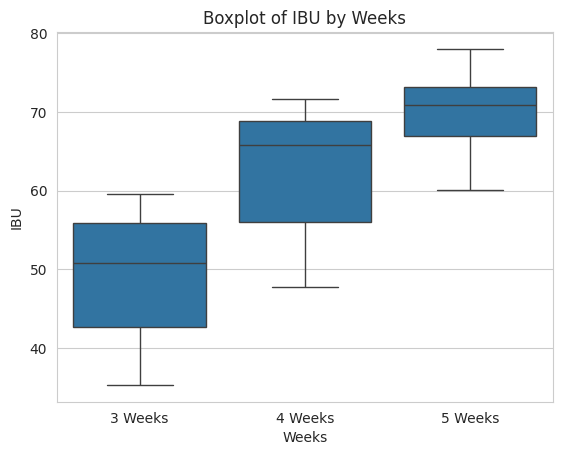

In [5]:

#%pip install openpyxl

## Import pandas ##

import pandas as pd

## Import IPA.xlsx File ##
IPA_data = pd.read_excel("/content/STAT-7220-Applied-Experimental-Design/Assignments/HW1/IPA.xlsx")

## Integrity Check ##
print(IPA_data.info())


## Group the dataframe by the "weeks"
## column and calculate mean/sd for the
## "IBU" column ##

summary_stats = IPA_data.groupby('Weeks')['IBU'].agg(['mean','std'])

print(summary_stats)

#####################################Data Visualization##################################
## Install matplotlib and seaborn ##

#%pip install matplotlib seaborn

import seaborn as sns
import matplotlib.pyplot as plt

## Set a nice minimal style for plot ##

sns.set_style("whitegrid")

## Create boxplot using seaborn ##

sns.boxplot(x="Weeks",y="IBU",data=IPA_data)

## Add Title and Labels using matplotlib ##

plt.title("Boxplot of IBU by Weeks", loc='center')
plt.xlabel("Weeks")
plt.ylabel("IBU")




**Question 7.** Build a one-way ANOVA model. Test the assumption of normality using **both** a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?


Assumption of normality:

The residuals are normally distributed
based on the Q-Q plot, most points fall near the line with minimal deviation. thus we can conclude that the Q-Q plot gives evidence in support of normality assumption

Shapiro-Wilk Test P-Value: 0.0630>0.05 which also means that the assumption of normality is supported by the data.




            df      sum_sq      mean_sq          F    PR(>F)
C(Weeks)   2.0  2174.83994  1087.419970  19.339842  0.000006
Residual  27.0  1518.12718    56.226933        NaN       NaN


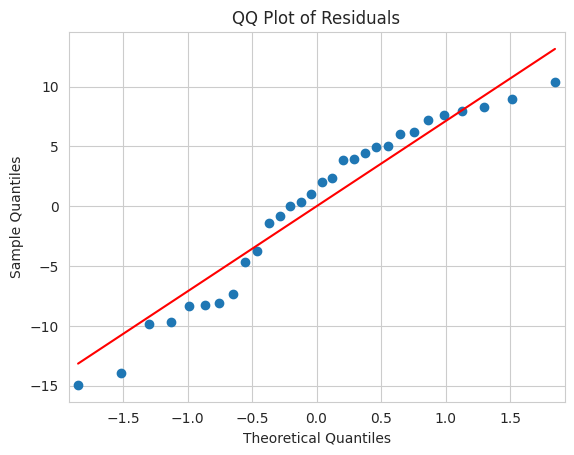

Shapiro-Wilk Test Statistic: 0.9341
Shapiro-Wilk Test P-Value: 0.0630
Fail to reject null hypothesis: Residuals are normally distributed.


In [9]:
###########  Building the one-way ANOVA model #######################################

## Install statsmodels.api ##
%pip install statsmodels

## Import statsmodels ##

import statsmodels.api as sm
from statsmodels.formula.api import ols

## Fit One-Way ANOVA Model ##
mod = ols("IBU ~ C(Weeks)", data=IPA_data).fit()

## Get the ANOVA table ##

aov_tab = sm.stats.anova_lm(mod,typ=1)

print(aov_tab)

##########################Assumption of normality using Q-Q Plot #########################################

## Install scipy package ##

%pip install scipy ##

## Import scipy ##

import scipy.stats as stats

## Extract Model Residuals ##

residuals = mod.resid

## Generate QQ plot using seaborn ##

sm.qqplot(residuals, line ='s')
plt.title("QQ Plot of Residuals")
plt.show()

####################Assumption of normality usuing Shapiro-wilk test ########################
## Perform Shapiro-Wilk Test of Normality ##
sw_test = stats.shapiro(residuals)
## Extract Test Stat and P-Value ##
sw_stat = sw_test.statistic
sw_pvalue = sw_test.pvalue
## Print Results ##
print(f"Shapiro-Wilk Test Statistic: {sw_stat:.4f}")
print(f"Shapiro-Wilk Test P-Value: {sw_pvalue:.4f}")
if sw_pvalue > 0.05:
    print("Fail to reject null hypothesis: Residuals are normally distributed.")
else:
    print("Reject null hypothesis: Residuals are not normally distributed.")


Question 8. Test the assumption of homogeneity of variance using both a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?

visual method:

- for each group mean (shown by the vertical lines), the residuals are mostly centered around 0
- there aren't any points greater than +3 or less than -3, which means that we are not observing any obvious outliers.
- the length of the vertical spread of the residuals for each group mean is relatively similar which indicates the constant variance.

we can  conclude that the constant variance assumption is reasonably supported by the data

The testing Method:  Bruesch-Pagan Test

because p-value: 0.2902941540365849 > 0.05
we Fail to reject null hypothesis: Homoscedasticity detected. therfore  Constant Variance assumed.



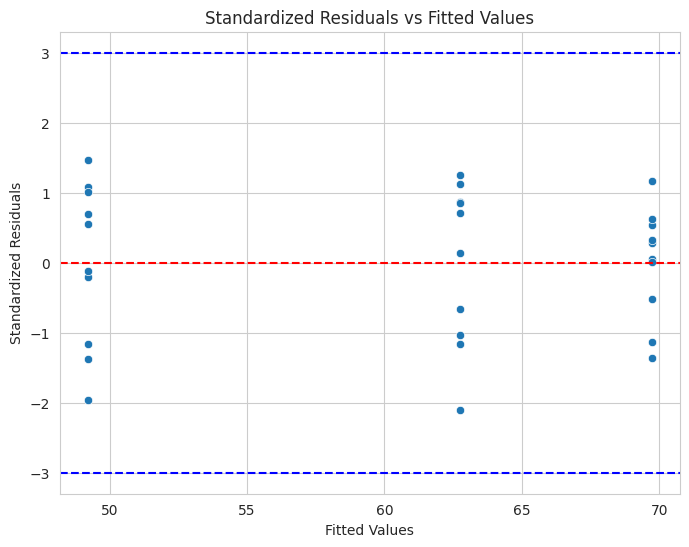

BP Test F-statistic: 1.2952914537529732
BP Test F p-value: 0.2902941540365849
Fail to reject null hypothesis: Homoscedasticity detected. Constant Variance assumed.


In [11]:

############################ Visual Method ##################################
## Obtain Standardized Residuals ##

standardized_residuals = mod.get_influence().resid_studentized_internal

## Get the fitted values ##

fitted_values = mod.fittedvalues

## Create the plot using seaborn ##

plt.figure(figsize=(8,6))
sns.scatterplot(x=fitted_values, y=standardized_residuals)
plt.axhline(0, color='red', linestyle='--')
plt.axhline(3, color='blue', linestyle='--')
plt.axhline(-3, color='blue', linestyle='--')
plt.title("Standardized Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Standardized Residuals")
plt.show()

####################### The testing Method:  Bruesch-Pagan Test######################

## Import necessary function: ##

from statsmodels.stats.diagnostic import het_breuschpagan

## Run B-P Test ##

bp_test = het_breuschpagan(mod.resid,mod.model.exog)

## Extract F-statistic ##

f_statistic = bp_test[2]

## Extract its P-Value ##

f_p_value = bp_test[3]

print(f"BP Test F-statistic: {f_statistic}")
print(f"BP Test F p-value: {f_p_value}")
if f_p_value > 0.05:
    print("Fail to reject null hypothesis: Homoscedasticity detected. Constant Variance assumed.")
else:
    print("Reject null hypothesis: Heteroscedasticity detected. Constant Variance not assumed.")


Question 9. Report the F-statistic and its associated p-value from the one-way ANOVA model. Which of our two hypotheses is more strongly supported? Why?


F_statistic :19.339842

associated p-value of 0.000006 .

This indicates that data more strongly support the alternative hypothesis, if we use our traditional  α -level of 0.05.

In [12]:

import numpy as np

## Print ANOVA Table Adding Significance Column ##

aov_tab = sm.stats.anova_lm(mod,typ=1)

aov_tab["Significant"] = np.where(aov_tab["PR(>F)"]<0.05,"Yes","No")

print(aov_tab)


            df      sum_sq      mean_sq          F    PR(>F) Significant
C(Weeks)   2.0  2174.83994  1087.419970  19.339842  0.000006         Yes
Residual  27.0  1518.12718    56.226933        NaN       NaN          No


Question 10. If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which aging times are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

Question 11. Write a brief, contextual conclusion summarizing the results of your analyses. Additionally, describe any limitations of the experiment and/or your analyses, and suggest potential improvements for future experiments of this nature.